### Notes

In [1]:

import os
import sys
sys.path.append('/home/hengjie/DL_projects/brainmets/1210_wip/0107')
from myRTDoseReader import myRTDoseReader

dir_base = "/database/brainmets/dicom/SBRT_research_mim_export_20251209_organized"


# # 0944.1998.11 (fail)
# path_dict = {
#     "MR":     "SRS0944/1998-11__Studies/SRS0944_SRS0944_MR_1998-11-12_000000_._axial_n45__00000",
#     "RTDOSE": "SRS0944/1998-11__Studies/SRS0944_SRS0944_RTDOSE_1998-11-12_000000_._._n1__00000",
# }

# 3126.2021.01 (success)
# path_dict = {
#     "MR":     "SRS3126/2011-01__Studies/SRS3126_SRS3126_MR_2011-01-07_083714_MR.STEREO.BRAIN_AX.T1.PG_n51__00000",
#     "RTDOSE": "SRS3126/2011-01__Studies/SRS3126_SRS3126_RTDOSE_2011-01-07_083714_MR.STEREO.BRAIN_._n1__00000",
# }


# 1669.2002.03 (fail)
path_dict = {
    "MR":     "SRS1669/2002-03__Studies/SRS1669_SRS1669_MR_2002-03-12_000000_._axial1_n22__00000",
    "RTDOSE": "SRS1669/2002-03__Studies/SRS1669_SRS1669_RTDOSE_2002-03-12_000000_._._n1__00000",
}

# 1669.2010.10 (success)
# path_dict = {
#     "MR":     "SRS1669/2010-10__Studies/SRS1669_SRS1669_MR_2010-10-04_091759_MR.STEREO.BRAIN_Ax.T1.PG_n51__00000",
#     "RTDOSE": "SRS1669/2010-10__Studies/SRS1669_SRS1669_RTDOSE_2010-10-04_091759_MR.STEREO.BRAIN_._n1__00000",
# }

folder_mr = os.path.join(dir_base, path_dict["MR"])
folder_rtdose = os.path.join(dir_base, path_dict["RTDOSE"])

In [2]:
import os
import SimpleITK as sitk


def read_dicom_series(folder: str, series_uid: str | None = None) -> tuple[sitk.Image, list[str], str]:
    """
    Read a DICOM series (3D volume) from a folder.

    If series_uid is None, it picks the series with the most slices.
    Returns (image, file_list, chosen_series_uid).
    """
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Not a folder: {folder}")

    series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(folder)
    if not series_ids:
        raise RuntimeError(f"No DICOM series found in: {folder}")

    if series_uid is None:
        # pick the series with the most files (usually the actual volume)
        best_id = None
        best_n = -1
        for sid in series_ids:
            files = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(folder, sid)
            if len(files) > best_n:
                best_n = len(files)
                best_id = sid
        series_uid = best_id

    file_list = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(folder, series_uid)
    if not file_list:
        raise RuntimeError(f"Series UID {series_uid} has no files in: {folder}")

    reader = sitk.ImageSeriesReader()
    reader.SetFileNames(file_list)

    # optional but often helpful for DICOM:
    reader.MetaDataDictionaryArrayUpdateOn()
    reader.LoadPrivateTagsOn()

    img3d = reader.Execute()
    return img3d, file_list, series_uid


def resample_to_reference(
    moving: sitk.Image,
    reference: sitk.Image,
    *,
    transform: sitk.Transform | None = None,
    interpolator: int | None = None,
    default_value: float = 0.0,
    output_pixel_type: int | None = None,
) -> sitk.Image:
    """
    Resample `moving` onto the grid of `reference`.

    Parameters
    ----------
    moving : sitk.Image
        Image to be resampled (e.g., RTDOSE).
    reference : sitk.Image
        Target grid (e.g., CT/MR DICOM image) providing spacing/origin/direction/size.
    transform : sitk.Transform | None
        Physical transform mapping reference -> moving. For same patient space, use identity.
        If you already registered images, pass that transform here.
    interpolator : int | None
        sitk interpolator. If None, auto-choose:
          - sitkLinear for scalar images (dose, CT, MR)
          - sitkNearestNeighbor for labels (mask)
    default_value : float
        Value for samples outside moving image support (dose outside grid -> 0).
    output_pixel_type : int | None
        Output pixel type. If None, keep moving's pixel type.

    Returns
    -------
    sitk.Image
        moving resampled onto reference grid.
    """
    if transform is None:
        transform = sitk.Transform(3, sitk.sitkIdentity)

    if interpolator is None:
        # Heuristic: use NN for integer-ish label images, linear otherwise.
        # RTDOSE is scalar -> linear.
        is_label_like = moving.GetPixelID() in (
            sitk.sitkUInt8, sitk.sitkInt8,
            sitk.sitkUInt16, sitk.sitkInt16,
            sitk.sitkUInt32, sitk.sitkInt32,
            sitk.sitkUInt64, sitk.sitkInt64,
        )
        interpolator = sitk.sitkNearestNeighbor if is_label_like else sitk.sitkLinear

    if output_pixel_type is None:
        output_pixel_type = moving.GetPixelID()

    return sitk.Resample(
        moving,
        reference,              # defines output grid
        transform,              # maps output (reference) physical points into moving
        interpolator,
        default_value,
        output_pixel_type,
    )


In [3]:
import numpy as np
import matplotlib.pyplot as plt

titles = ["Axial MIP (max over z/SI)", "Coronal MIP (max over y/AP)", "Sagittal MIP (max over x/LR)"]

def plot_3view_mip(
    vol_zyx: np.ndarray,
    *,
    titles_3=titles,
    cmap=None,
    origin="lower",
    p_lo=1,
    p_hi=99,
    vmin=None,
    vmax=None,
    assume_nonnegative=False,
    add_colorbar=False,
    figsize=(15, 5),
    suptitle=None,
):
    """
    Plot 3-view MIPs (Axial/Coronal/Sagittal) from a 3D numpy array in (z,y,x) order.

    Parameters
    ----------
    vol_zyx : np.ndarray
        3D volume with shape (z, y, x).
    titles_3 : list[str]
        3 titles for the 3 panels.
    cmap : str | None
        Matplotlib colormap. Use 'gray' for MR/CT.
    p_lo, p_hi : float
        Percentile clipping for display if vmin/vmax are not provided.
    vmin, vmax : float | None
        Display range. If None, uses robust percentiles.
    assume_nonnegative : bool
        If True and vmin is None, uses vmin=0 (useful for dose).
    add_colorbar : bool
        If True, adds a colorbar to each panel.
    """
    vol = np.asarray(vol_zyx)
    if vol.ndim != 3:
        raise ValueError(f"Expected a 3D array (z,y,x). Got shape={vol.shape}")

    # 3-view MIPs from (z,y,x)
    mips = [
        np.nanmax(vol, axis=0),  # axial: (y,x)
        np.nanmax(vol, axis=1),  # coronal: (z,x)
        np.nanmax(vol, axis=2),  # sagittal: (z,y)
    ]

    def _robust_range(img):
        x = img[np.isfinite(img)]
        if x.size == 0:
            return (0.0, 1.0)
        lo, hi = np.percentile(x, [p_lo, p_hi])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.nanmin(img)), float(np.nanmax(img))
        if assume_nonnegative:
            lo = 0.0 if (vmin is None) else lo
        return lo, hi

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    if suptitle:
        fig.suptitle(suptitle)

    for ax, img, t in zip(axes, mips, titles_3):
        if vmin is None or vmax is None:
            lo, hi = _robust_range(img)
            _vmin = lo if vmin is None else vmin
            _vmax = hi if vmax is None else vmax
        else:
            _vmin, _vmax = vmin, vmax

        im = ax.imshow(img, cmap=cmap, origin=origin, vmin=_vmin, vmax=_vmax)
        ax.set_title(t)
        ax.axis("off")
        if add_colorbar:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    return fig, axes


In [4]:
mr_img, mr_files, mr_uid = read_dicom_series(folder_mr)
print("======================================== MR ========================================")
print(path_dict["MR"])
print("MR series UID:", mr_uid)
print("MR size          :", mr_img.GetSize())
print("MR spacing       :", mr_img.GetSpacing())
print("MR origin        :", mr_img.GetOrigin())
print("MR direction     :", mr_img.GetDirection())

# for mr_file in mr_files:
#     print(mr_file)

rtdose_reader = myRTDoseReader(folder_rtdose)
rtdose_img = rtdose_reader.get_image(apply_dose_scaling=True)
# rtdose_img = rtdose_reader.get_image(apply_dose_scaling=False)
print("====================================== RTDOSE ======================================")
print(path_dict["RTDOSE"])
print("RTDOSE size      :", rtdose_img.GetSize())
print("RTDOSE spacing   :", rtdose_img.GetSpacing())
print("RTDOSE origin    :", rtdose_img.GetOrigin())
print("RTDOSE direction :", rtdose_img.GetDirection())

# Print metadata using pydicom
# rtdose_reader.print_metadata_pydicom()

======================================== MR ========================================
SRS1669/2002-03__Studies/SRS1669_SRS1669_MR_2002-03-12_000000_._axial1_n22__00000
MR series UID: 2.16.840.1.114362.1.12046989.25631758973.631603556.105.3919
MR size          : (256, 256, 22)
MR spacing       : (1.0, 1.0, 1.0)
MR origin        : (0.0, 0.0, 0.0)
MR direction     : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
====================================== RTDOSE ======================================
SRS1669/2002-03__Studies/SRS1669_SRS1669_RTDOSE_2002-03-12_000000_._._n1__00000
RTDOSE size      : (335, 372, 351)
RTDOSE spacing   : (0.5, 0.5, 0.5)
RTDOSE origin    : (60.191863, 43.0818047, 14.4409215)
RTDOSE direction : (1.0, -2.03329793e-19, -5.89739504e-19, 2.0332979300000007e-19, 1.0, 1.13593529e-16, -5.89739504e-19, 1.13593529e-16, -1.0)


In [5]:
print(mr_img.GetOrigin())
print(mr_img.GetSpacing())
mr_img.SetOrigin((0.0, 0.0, -124.50574493408))
mr_img.SetSpacing((1.1767129898071, 1.1767129898071, 5.928848266599999))
print(mr_img.GetOrigin())
print(mr_img.GetSpacing())

(0.0, 0.0, 0.0)
(1.0, 1.0, 1.0)
(0.0, 0.0, -124.50574493408)
(1.1767129898071, 1.1767129898071, 5.928848266599999)


In [6]:
dose_on_mr = resample_to_reference(
    moving=rtdose_img,
    reference=mr_img,
    interpolator=sitk.sitkLinear,
    default_value=0.0,
    output_pixel_type=sitk.sitkFloat32,
)

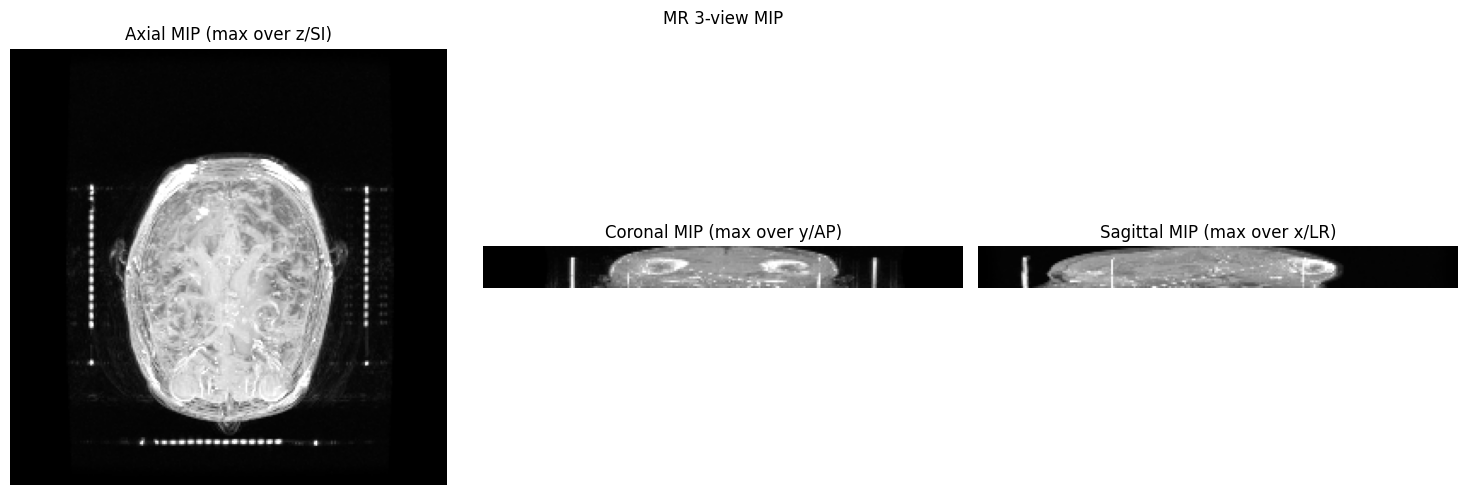

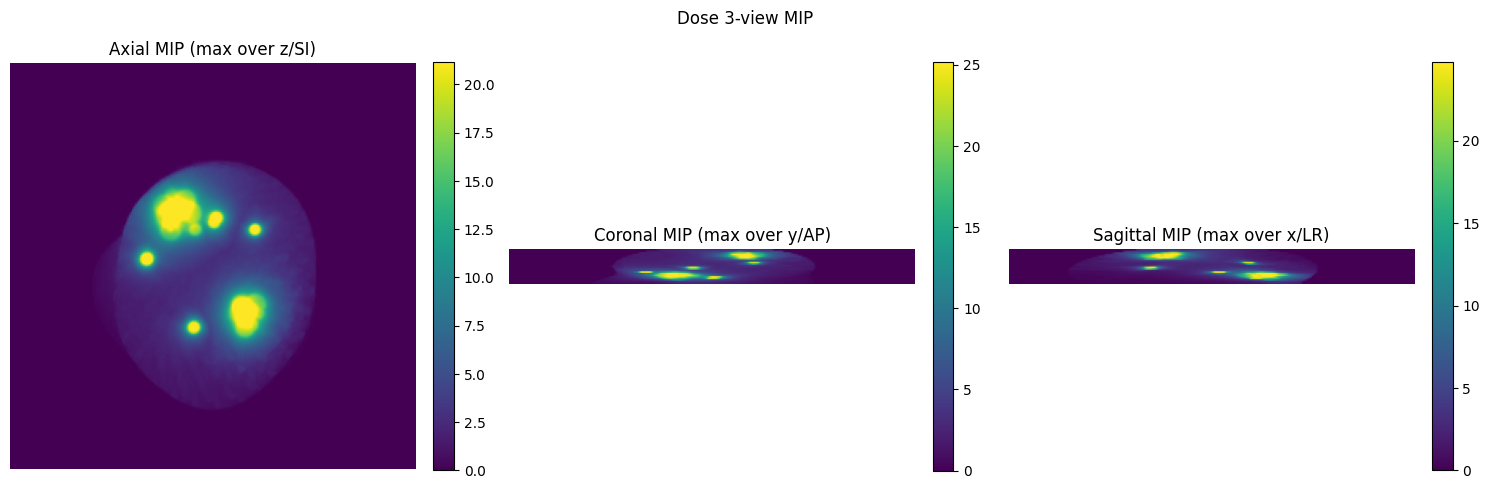

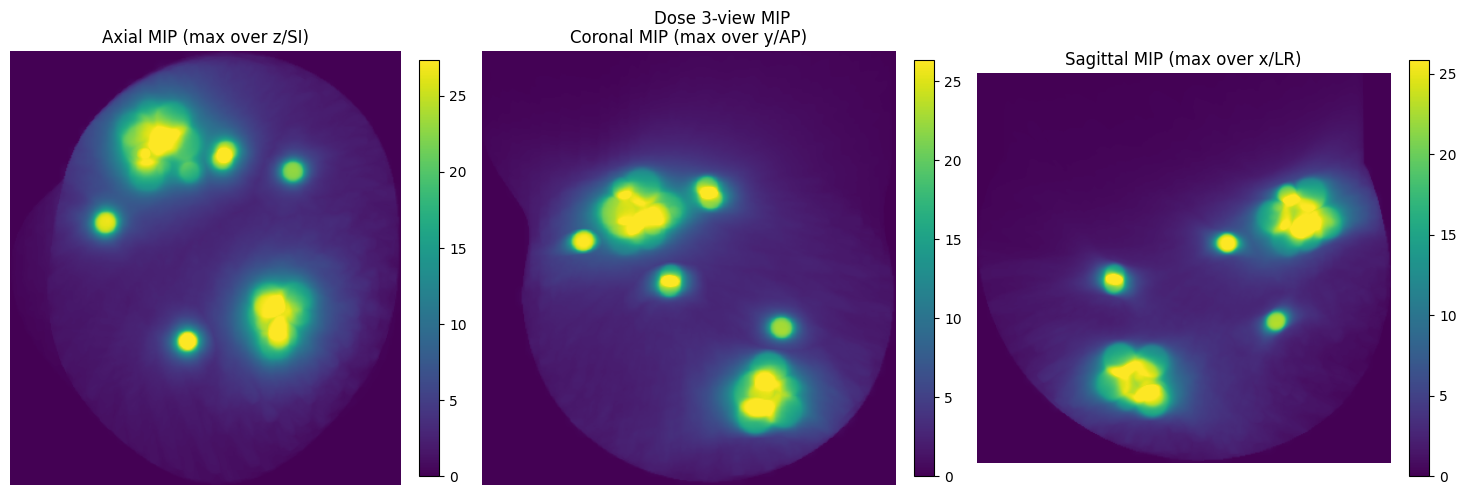

(<Figure size 1500x500 with 6 Axes>,
 array([<Axes: title={'center': 'Axial MIP (max over z/SI)'}>,
        <Axes: title={'center': 'Coronal MIP (max over y/AP)'}>,
        <Axes: title={'center': 'Sagittal MIP (max over x/LR)'}>],
       dtype=object))

In [7]:
plot_3view_mip(sitk.GetArrayFromImage(mr_img).astype(np.float32), cmap="gray", suptitle="MR 3-view MIP")
plot_3view_mip(sitk.GetArrayFromImage(dose_on_mr).astype(np.float32), assume_nonnegative=True, suptitle="Dose 3-view MIP", add_colorbar=True)
plot_3view_mip(sitk.GetArrayFromImage(rtdose_img).astype(np.float32), assume_nonnegative=True, suptitle="Dose 3-view MIP", add_colorbar=True)